## 1) XGBoost
* 트리 기반의 앙상블 학습에서 가장 각광받고 있는 알고리즘 중 하나
* GBM에 기반하나, 그 단점인 느린 수행시간&과적합 규제 부재 등의 문제 해결
* 병렬 CPU 환경에서 병렬 학습이 가능 -> 기존 GBM보다 빠르게 학습 수행 가능
* 장점
  * 뛰어난 예측 성능 : 분류, 회귀에서 특히
  * GBM 대비 빠른 수행 시간
    * 일반적 GBM : 순차적으로 약한 학습기가 가중치를 증감하는 방법으로 학습 -> 수행 속도 느림
    * XGBoost : 병렬 수행 및 다양한 기능 -> 빠른 수행 시간 (랜덤 포레스트 등에 대해서 빠르단 건 아님)
  * 과적합 규제(regularization)
  * Tree Pruning(나무 가지치기) : max_depth 파라미터로 분할 깊이 조정하기도 하나, 가지치기로 더이상 긍정 이득이 없는 분할을 가지치기 해서 분할의 수를 줄임
  * 자체 내장된 교차 검증 : 반복 수행시마다 내부적으로 학습 데이터셋과 평가 데이터셋에 대한 교차 검증을 수행 -> 최적화된 반복 수행 횟수 가짐. 최적화되면 반복을 중간에 멈추는 조기 중단 기능 가짐
  * 결손값 자체 처리 기능
* 핵심 라이브러리는 C/C++로 작성됨 -> 사이킷런과 연동할 수 있는 래퍼 클래스(Wrapper) 제공 -> XGBCLassifier, XGBRegressor

In [4]:
import xgboost as xgb
from xgboost import XGBClassifier

NameError: name 'functoolz' is not defined

## 2) 파이썬 래퍼 XGBoost



* 사이킷런과의 차이 : 학습용과 테스트용 세트를 위해 별도의 객체 DMatrix 생성
  * 주로 넘파이 배열을 입력 파라미터로 받아 만들어지는 XGBoost 만의 전용 데이터셋
  * 주요 입력 파라미터는 data(피처 데이터셋)와 label(분류에서는 레이블 데이터. 회귀에서는 숫자형인 종속 데이터셋)
  * libsvm txt 포맷 파일, xgboost 이전 버퍼 파일도 파라미터로 받을 수 있음
  * DataFrmae으로 데이터 인터페이스 하려면 DataFrame.values를 이용해 넘파이로 일차 변환 -> DMatrix 변환 해야 함  
* 하이퍼 파라미터 설정
  * 주로 딕셔너리 형태로 입력
  * max_depth, eta(학습률. XGBClassifier에서는 learning_rate), objective(목적함수), eval_metric(오류 함수의 평가지표), early_stoppings, num_rounds(부스팅 반복 횟수)
* 조기 중단 기능
  * 학습 시 수행 속도를 개선하기 위해 조기 중단 기능 제공
  * 더이상 지표 개선이 없을 경우 num_boost_round 횟수를 모두 채우지 않고, 중간에 반복을 빠져나올 수 있도록 함
  * train() 함수에 early_stoppping_rounds 파라미터르 ㄹ입력하여 설정함
  * eval_set(성능 평가 수해할 평가용 데이터셋 설정), eval_metric(평가 세트에 적용할 성능 평가방법. 분류에서는 주로 error(분류 오류), logloss 적용)이 함께 설정되어야 함
  * 반복마다 eval_set으로 지정된 데이터셋에서 eval_metric의 지정된 평가 지표로 예측 오류 측정함
* train() 함수를 호출해 학습이 완료된 모델 객체 반환 -> predict()로 예측함
  * 사이킷런의 predit()는 예측 결과 클래스값(0, 1)을 반환
  * xgboost의 predict()는 예측 결과를 추정할 수 있는 확률값을 반환. 예측 결괏값(X)
* 시각화 plot_importance()
  * 피처의 중요도를 막대그래프 형식으로 나타냄
  * 기본 평가 지표 = f1 스코어
  * xboost 넘파이 기반의 피처 데이터로 학습 시에 피처명을 제대로 알 수 없음 -> f0, f1 같이 피처 순서별로 f자 뒤에 순서 붙여 X축에 피처 들로 나열
* 트리 기반 규칙 구조를 xgboost에서 시각화 가능 : to_graphvix() API
* 데이터셋에 대한 교차 검증 수행 후 최적 파라미터 구하기 : cv() API

# 파이썬 래퍼 XGBoost 하이퍼 파라미터
* GBM과 유사한 하이퍼 파라미터 동일하게 가지고 있음 + 조기 중단과 과적합 규제위한 파라미터
* 사이킷런 래퍼 모듈과는 약간 다르므로 주의할 것
* 유형
  * 일반 파라미터 : 실행 시 스레드 개수, silent 모드 등 선택. 디폴트 파라미터 값을 잘 바꾸지는 않음
    * booster, silent, nthread
  * 부스터 파라미터 : 트리 최적화, 부스팅, 규제 등 파라미터. 대부분 파라미터는 여기 속함
    * eta : GBM의 학습률과 같은 파라미터. 0-1사이 값. 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률값. 기본은 0.3. 사이킷런 래퍼 클래스는 'learning_rate'임(기본 0.01~0.02)
    * num_boost_rounds : GBM의 n_estimator와 같음
    * min_child_weight : 트리에서 추가적으로 가지를 나눌지 결정한 데이터들의 weight 총합. 클수록 분할 자제함. 과적합 규제 위함. 기본은 1
    * gamma : 트리 리프 노드 추가적으로 나눌지 결정할 최소 손실 감소값. 해당값보다 큰 손실이 감소된 경우 리프 노드를 분리. 클수록 과적합 잘 감소시킴. 기본은 0. min_split_loss와 비슷
    * max_depth : 트리 기반의 max_depth와 동일. 0 지정하면 깊이 제한 없음. 높으면 특정 피처에 특화되어 과적합 위험. 보통 3-10 사이값이며 기본은 6
    * sub_sample : GBM의 subsample과 동일. 트리가 커져서 과적합되는 것을 제어하려 데이터를 샘플링하는 비율. 0.5이면 전체 데이터 절반을 트리를 생성하는 데 사용. 0-1 사잇값 가능. 일반적으로 0.5-1 지정. 기본은 1
    * comsample_bytree : GBM의 max_features와 유사. 트리 생성에 필요한 피처를 임의로 샘플링. 많은 피처 있을 경우 과적합 할 때 사용. 기본은 1
    * lambda : 기본은 1. L2규제 적용값. 피처 많을 때 이 값이 클 수록 과적합 감소 효과. reg_lambda와 비슷. 기본은 1
    * alpha : 기본은 0, reg_alpha와 비슷. L1 규제 적용값. 피처 많을 경우 이 값이 클 수록 과적합 감소 효과.
    * scale_pos_weight : 기본은 1, 특정값으로 치우친 비대칭 클래스로 구성된 데이터셋의 균형 유지하기 위한 파라미터
  * 학습 태스크 파라미터 : 학습 시 객체 함수, 평가 위한 지표 등
    * objective : 최솟값을 가져야할 손실 함수. 많은 유형의 손실함수 사용 가능. 이진분류인지 다중분류인지 따라 손실함수 달라짐
    * binary:logistic : 이진 분류일 때 적용
    * multi:softmax : 다중 분류일 때 적용. 손실함수가 이것일 경우, 레이블 클래스 개수인 num_class 파라미터 지정해야 함
    * multi:softprob : multi:softmax와 유사하나, 개별 레이블 크랠스의 해당되는 예측확률을 반환
    * eval_metric : 검증에 사용되는 함수를 정의. 기본값인 회귀는 rmse, 분류일 때는 error. 그 외로 mae, logloss, merror, mlogloss, auc 등
* RMSE (Root Mean Square Error) / mae(Mean Absolute Error) / logloss(Negative log-likelihood) / error(Binary classification error rate) / merror(Multiclass classification error rate) / mlogloss(Multiclass logloss) / auc(Area under the curve)
* 피처 수가 매우 많거나 피처 간 상관되는 정도가 많거나 데이터 세트에 따라 여러가지 특성 있을 수도
* 과적합 문제가 심각하다면 고려할 것
  * eta값 낮추기. num_round 높이기
  * max_depth값 낮추기
  * min_child_weight 값 높이기
  * gamma 값을 높이기
  * subsample, colsample_bytree 조정 등

## 3) 파이썬 래퍼 XGBoost 적용 : 위스콘신 유방암 예측
* 종양의 크기, 모양 등의 다양한 속성값을 기반으로 악성 종양(malignant)인지 양성 종양(benign)인지 분류한 데이터셋

In [5]:
### 데이터 불러오기

import xgboost as xgb
from xgboost import plot_importance # 피처의 중요도를 시각화해주는 모듈
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
x_features = dataset.data
y_label = dataset.target
cancer_df = pd.DataFrame(data=x_features, columns=dataset.feature_names)
cancer_df['target']=y_label
cancer_df.head(3)

NameError: name 'functoolz' is not defined

In [3]:
### 레이블값의 분포 확인

print(dataset.target_names) #악성이 0, 양성이 1
print(cancer_df['target'].value_counts())

['malignant' 'benign']
1    357
0    212
Name: target, dtype: int64


In [4]:
### 데이터셋 분할

x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size=0.2, random_state=156)
print(x_train.shape, x_test.shape)

(455, 30) (114, 30)


In [6]:
### DMatirx 변환

dtrain = xgb.DMatrix(data=x_train, label=y_train)
dtest = xgb.DMatrix(data=x_test, label=y_test)

In [7]:
### 하이퍼 파라미터 세팅

# 예제 데이터가 0 또는 1 이진 분류임 -> 목적함수로 이진 로지스틱 사용(binary logistic)
params = {
    'max_depth' : 3,
    'eta' : 0.1,
    'objective' : 'binary:logistic',
    'eval_metric' : 'logloss',
    'early_stoppings' : 100
}
num_rounds = 400

In [8]:
### 조기 중단 파라미터 설정

wlist = [(dtrain, 'train'), (dtest, 'eval')] #학습 데이터셋은 train, 평가 데이터셋은 eval로 표기함
xgb_model = xgb.train(params=params, dtrain=dtrain, num_boost_round=num_rounds, early_stopping_rounds=100, evals=wlist)

[17:20:14] WARNING: ..\src\learner.cc:541: 
Parameters: { early_stoppings } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[0]	train-logloss:0.60969	eval-logloss:0.61352
[1]	train-logloss:0.54080	eval-logloss:0.54784
[2]	train-logloss:0.48375	eval-logloss:0.49425
[3]	train-logloss:0.43446	eval-logloss:0.44799
[4]	train-logloss:0.39055	eval-logloss:0.40911
[5]	train-logloss:0.35414	eval-logloss:0.37498
[6]	train-logloss:0.32122	eval-logloss:0.34571
[7]	train-logloss:0.29259	eval-logloss:0.32053
[8]	train-logloss:0.26747	eval-logloss:0.29721
[9]	train-logloss:0.24515	eval-logloss:0.27799
[10]	train-logloss:0.22569	eval-logloss:0.26030
[11]	train-logloss:0.20794	eval-logloss:0.24604
[12]	train-logloss:0.19218	eval-logloss:0.23156
[13]	train-logloss:0.17792	eval-logloss:0.22005
[14

[163]	train-logloss:0.00722	eval-logloss:0.08778
[164]	train-logloss:0.00720	eval-logloss:0.08778
[165]	train-logloss:0.00718	eval-logloss:0.08752
[166]	train-logloss:0.00716	eval-logloss:0.08754
[167]	train-logloss:0.00714	eval-logloss:0.08764
[168]	train-logloss:0.00712	eval-logloss:0.08739
[169]	train-logloss:0.00710	eval-logloss:0.08738
[170]	train-logloss:0.00708	eval-logloss:0.08730
[171]	train-logloss:0.00707	eval-logloss:0.08737
[172]	train-logloss:0.00705	eval-logloss:0.08740
[173]	train-logloss:0.00703	eval-logloss:0.08739
[174]	train-logloss:0.00701	eval-logloss:0.08713
[175]	train-logloss:0.00699	eval-logloss:0.08716
[176]	train-logloss:0.00697	eval-logloss:0.08696
[177]	train-logloss:0.00696	eval-logloss:0.08705
[178]	train-logloss:0.00694	eval-logloss:0.08697
[179]	train-logloss:0.00692	eval-logloss:0.08697
[180]	train-logloss:0.00690	eval-logloss:0.08704
[181]	train-logloss:0.00688	eval-logloss:0.08680
[182]	train-logloss:0.00687	eval-logloss:0.08683
[183]	train-logloss:

In [9]:
### 예측 수행

pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결괏값을 10개만 표시. 예측 확률값으로 표시됨')
print(np.round(pred_probs[:10], 3))

#예측 확률이 0.5보다 크면 1, 아니면 0으로 예측값 결정 -> 리스트 객체인 preds에 저장
preds = [1 if x>0.5 else 0 for x in pred_probs]
print("예측값 10개만 표시 : ", preds[:10])

predict() 수행 결괏값을 10개만 표시. 예측 확률값으로 표시됨
[0.934 0.003 0.91  0.094 0.993 1.    1.    0.999 0.997 0.   ]
예측값 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [11]:
### 모델의 예측 성능 평가

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    print('오차행렬 : ')
    print(confusion)
    print('정확도 : {0:.4f} , 정밀도 : {1:.4f} , 재현율 : {2:.4f}'.format(accuracy, precision, recall))
    
get_clf_eval(y_test, preds)

오차행렬 : 
[[35  2]
 [ 1 76]]
정확도 : 0.9737 , 정밀도 : 0.9744 , 재현율 : 0.9870


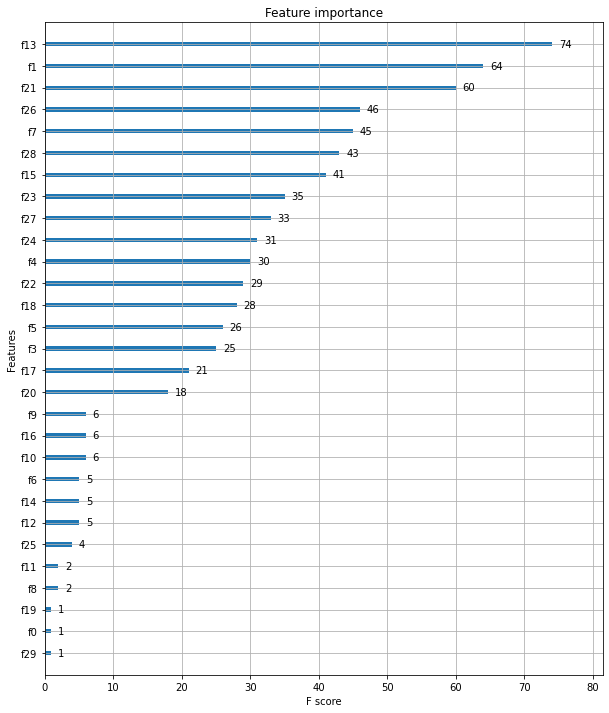

In [13]:
### 시각화 기능

from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)

* 결정 트리의 트리 기반 규칙 구조도 xgboost에서 시각화 가능 -> to_graphviz() API
  * Graphviz 프로그램과 패키지 설정되어있어야함
  * xgboost.to_graphviz() 내에 파라미터로 '파라미터로 학습이 완료된 모델 객체'와 'Graphviz가 참조할 파일명' 입력
* 사이킷런 GridSearchCV와 유사하게 데이터셋 대한 교차 검증 수행 후 최적 파라미터 구하는 방법 제공 -> cv() API
  * params : dict. 부스터 파라미터
  * dtrain : DMatricx. 학습 데이터
  * num_boost_round : int. 부스팅 반복 횟수
  * nfold : int. CV 폴드 개수
  * stratified : bool. CV 수행 시 층화 표본 추출(stratified sampling) 수행 여부
  * metrics : string/list of strings. CV 수행 시 모니터링할 성능 평가 지표
  * early_stopping_rounds : int. 조기 중단을 활성화시킴. 반복 횟수 지정

## 4) 사이킷런 래퍼 XGBoost
* XGBoost 개발 그룹은 사이킷런의 프레임워크와 연동하기 위해 사이킷런 전용의 래퍼 클래스 개발함
* 다른 Estimator와 동일하게 fit, predict 사용 가능. GridSearchCV, Pipeline 등의 사이킷런 유틸리티 사용 가능
* 분류 래퍼 클래스인 XGBClassifier, 회귀 래퍼 클래스인 XGBRegressor
* 기존 사이킷런에서 일반적으로 사용하는 파라미터와 호환성 유지 위해 기존 xgboost 모듈 네이티브 하이퍼 파라미터 변경
  * eta -> learning_rate
  * sub_sample -> subsample
  * lambda -> reg_lambda
  * alpha -> reg_alpha

In [1]:
from xgboost import XBGClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)
xgb_wrapper.fit(x_train, y_train)
w_preds = xgb_wrapper.predict(x_test)
w_pred_proba = xgb_wrapper.predict_proba(x_test)[:, 1]
get_clf_eval(y_test, w_preds, w_pred_proba)

KeyboardInterrupt: 

* 조기 중단 수행 가능 : fit()에 조기 중단 파라미터 입력
  * early_stopping(평가 지표가 향상될 수 있는 반복 횟수 정의), eval_metric(조기 중단을 위한 평가 지표), eval_set(성능 평가 수행할 데이터셋, 별도의 데이터셋이어야 함)
  * 아래 예시에서는 '평가를 위한 데이터 셋으로 테스트 데이터셋을 사용했으나, 바람직하지는 않음. 과적합 위험 있음. 학습 시 완전히 알렺지 않은 데이터를 사용해야 함
* 조기 중단값을 너무 급격히 줄이면 예측 성능이 저하됨. early_stopping_rounds=10으로 하면 반복 동안 성능평가 지수 향상되지 못해 학습 종료하게 됨

In [ ]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)
evals=[(x_test, y_test)]
xgb_wrapper.fit(x_train, y_train, early_stopping_rounds=100, eval_metric="logloss", eval_set=evals, verbose=True)
ws100_preds = xgb_wrapper.predict(x_test)
ws100_pred_proba = xgb_wrapper.predict(x_test)[:, 1]
  # 조기중단됨. 성능 평가 지수가 향상되지 않으므로

In [ ]:
get_clf_eval(y_test, ws100_preds, ws100_pred_proba)

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_wrapper, ax=ax) #사이킷런 래퍼 클래스 써도 무방